In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv("customer_support_tickets.csv")

print(data.head())
print(data.info())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [3]:
print(data.columns)


Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [4]:
data['First Response Time'] = pd.to_datetime(data['First Response Time'])
data['Time to Resolution'] = pd.to_datetime(data['Time to Resolution'])

data['Resolution_Time_Hours'] = (
    data['Time to Resolution'] - data['First Response Time']
).dt.total_seconds() / 3600

In [5]:
data.drop(['First Response Time','Time to Resolution'], axis=1, inplace=True)

In [6]:
data.drop(['Ticket Subject','Ticket Description','Resolution'], axis=1, inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [8]:
X = data.drop('Customer Satisfaction Rating', axis=1)
y = data['Customer Satisfaction Rating']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
print(X.dtypes)

Ticket ID                  int64
Customer Name              int64
Customer Email             int64
Customer Age               int64
Customer Gender            int64
Product Purchased          int64
Date of Purchase           int64
Ticket Type                int64
Ticket Status              int64
Ticket Priority            int64
Ticket Channel             int64
Resolution_Time_Hours    float64
dtype: object


In [11]:
data = data.dropna(subset=['Customer Satisfaction Rating'])

In [12]:
X = data.drop('Customer Satisfaction Rating', axis=1)
y = data['Customer Satisfaction Rating']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2075812274368231

Classification Report

              precision    recall  f1-score   support

         1.0       0.19      0.19      0.19       109
         2.0       0.24      0.21      0.22       117
         3.0       0.20      0.24      0.22       112
         4.0       0.22      0.21      0.21       108
         5.0       0.19      0.19      0.19       108

    accuracy                           0.21       554
   macro avg       0.21      0.21      0.21       554
weighted avg       0.21      0.21      0.21       554


Confusion Matrix

[[21 16 24 28 20]
 [18 24 37 19 19]
 [26 24 27 13 22]
 [23 15 24 23 23]
 [20 19 26 23 20]]


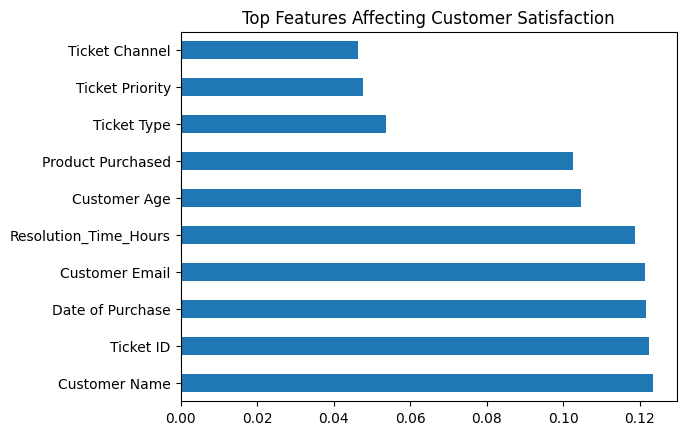

In [17]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh')

plt.title("Top Features Affecting Customer Satisfaction")

plt.show()

In [18]:
channel_map = {
0: 'Chat',
1: 'Email',
2: 'Phone',
3: 'Social Media'
}

data['Ticket Channel'] = data['Ticket Channel'].map(channel_map)

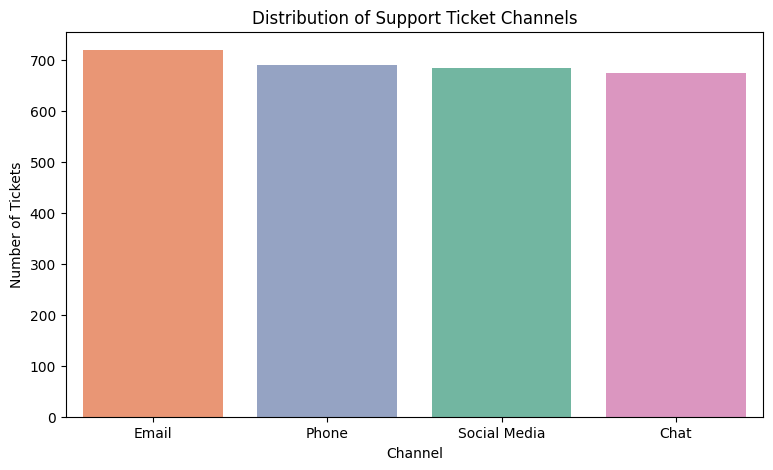

In [19]:
plt.figure(figsize=(9,5))

sns.countplot(
    x='Ticket Channel',
    data=data,
    hue='Ticket Channel',
    order=data['Ticket Channel'].value_counts().index,
    palette='Set2',
    legend=False
)

plt.title("Distribution of Support Ticket Channels")
plt.xlabel("Channel")
plt.ylabel("Number of Tickets")

plt.show()

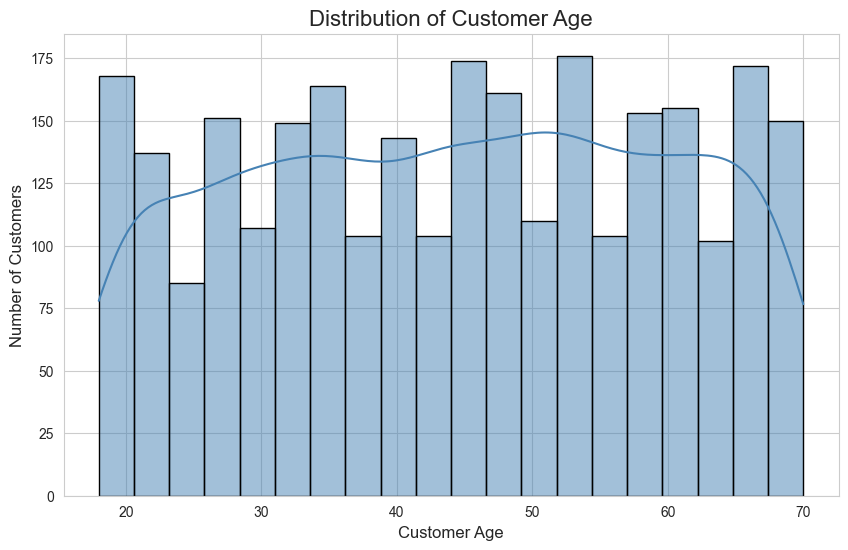

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Plot histogram
sns.histplot(
    data['Customer Age'],
    bins=20,
    kde=True,
    color='steelblue',
    edgecolor='black'
)

# Titles and labels
plt.title("Distribution of Customer Age", fontsize=16)
plt.xlabel("Customer Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Show plot
plt.show()

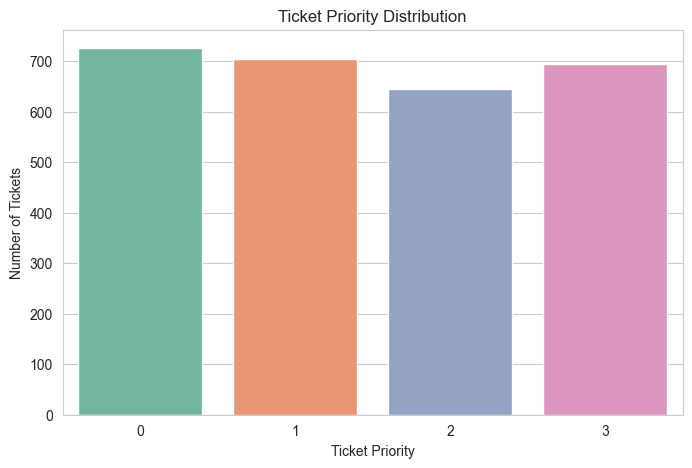

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Ticket Priority',
    data=data,
    hue='Ticket Priority',
    palette='Set2',
    legend=False
)

plt.title("Ticket Priority Distribution")
plt.xlabel("Ticket Priority")
plt.ylabel("Number of Tickets")

plt.show()

In [22]:
data['Ticket Type'] = data['Ticket Type'].map({
0:'Billing inquiry',
1:'Cancellation request',
2:'Product inquiry',
3:'Refund request',
4:'Technical issue'
})

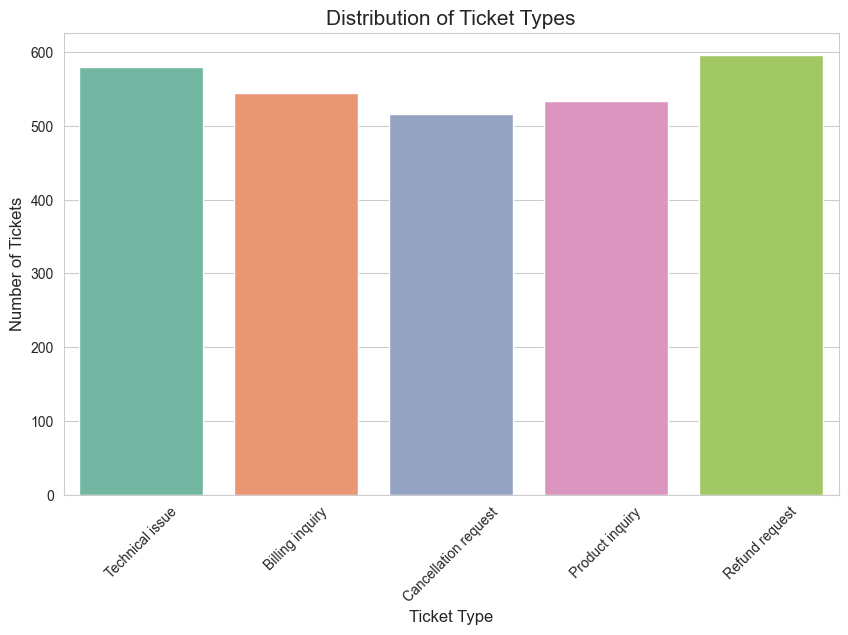

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    x='Ticket Type',
    data=data,
    hue='Ticket Type',
    palette='Set2',
    legend=False
)

plt.title("Distribution of Ticket Types", fontsize=15)
plt.xlabel("Ticket Type", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)

plt.xticks(rotation=45)

plt.show()

In [24]:
print(data['Product Purchased'].unique())

[10 25  5 30 27 38 40  9 12 15 16 18 19 31 21 28  3 37  8 11 34 33 39 35
  4  1 41 17  0 22 32  7 14 36 24 26 20  2  6 13 23 29]


In [25]:
data = pd.read_csv("customer_support_tickets.csv")

# Remove extra spaces
data.columns = data.columns.str.strip()

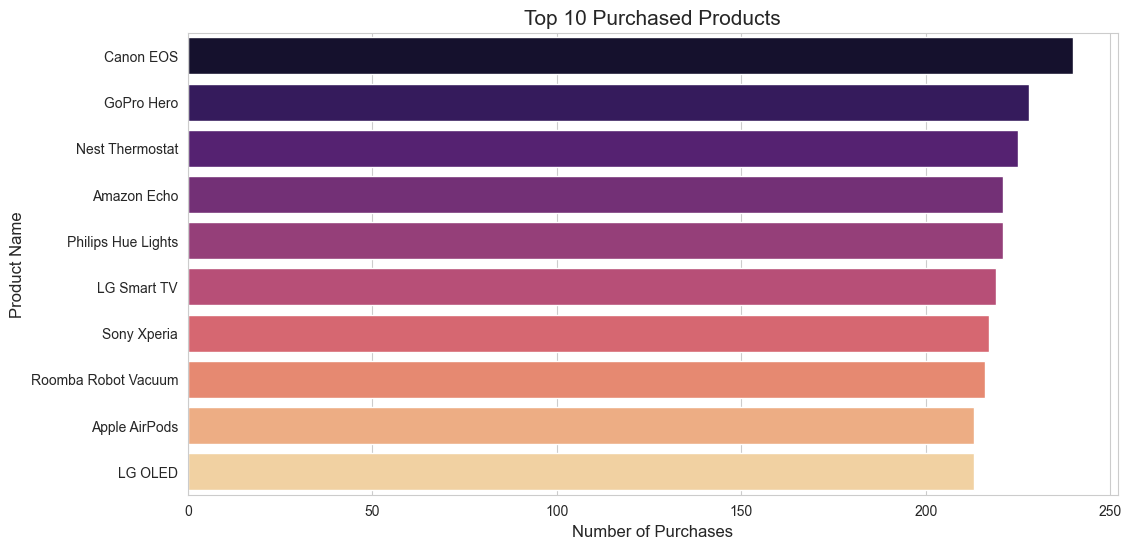

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_products = data['Product Purchased'].value_counts().head(10)

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette='magma',
    legend=False
)

plt.title("Top 10 Purchased Products", fontsize=15)
plt.xlabel("Number of Purchases", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.show()

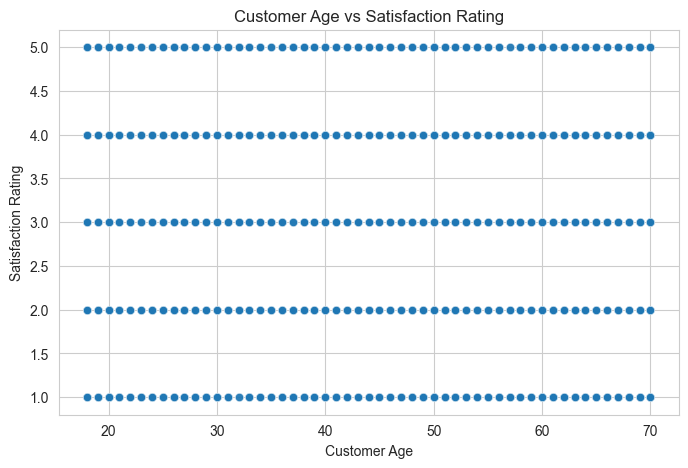

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Customer Age',
    y='Customer Satisfaction Rating',
    data=data,
    alpha=0.6
)

plt.title("Customer Age vs Satisfaction Rating")
plt.xlabel("Customer Age")
plt.ylabel("Satisfaction Rating")

plt.show()

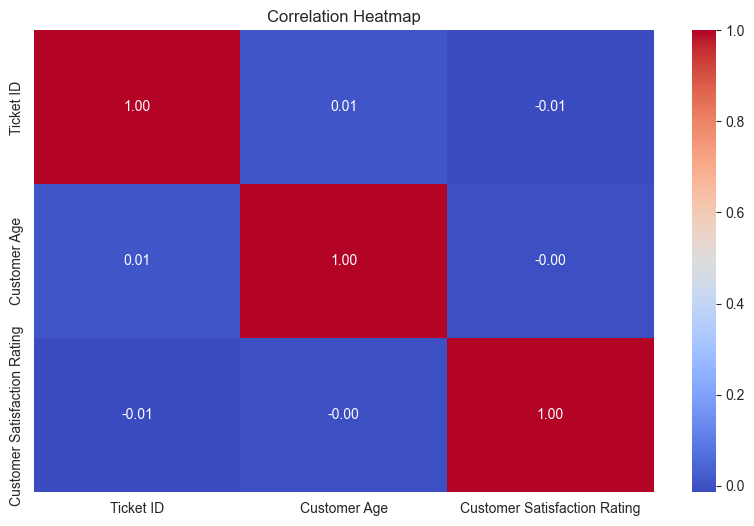

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    data.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

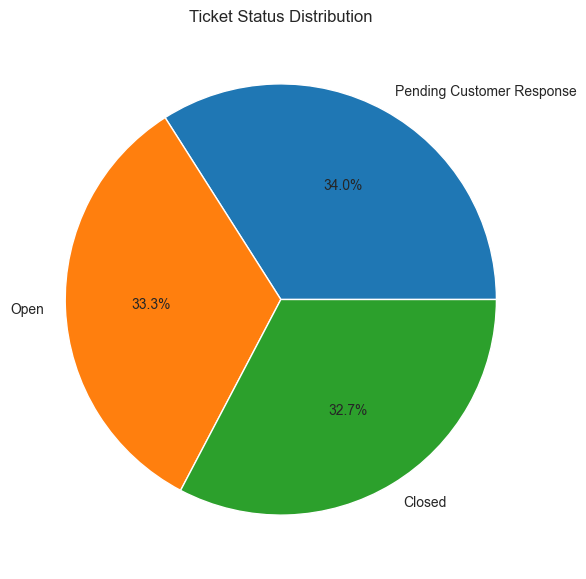

In [29]:
plt.figure(figsize=(7,7))

status_counts = data['Ticket Status'].value_counts()

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title("Ticket Status Distribution")

plt.show()

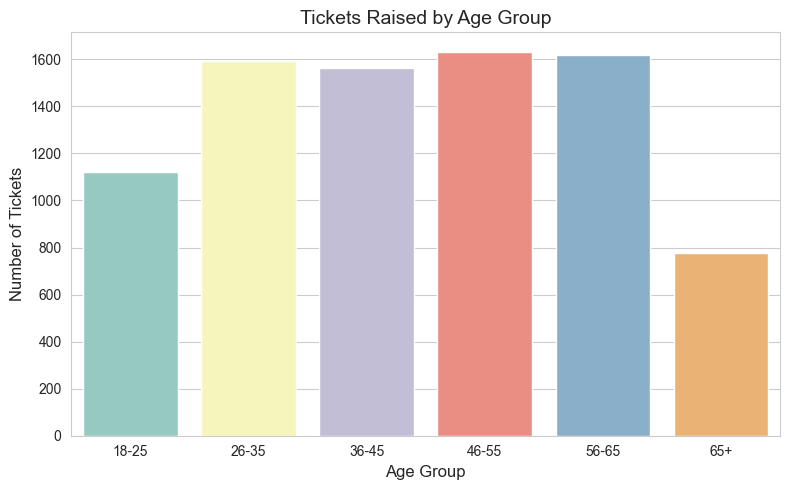

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age bins
bins = [18,25,35,45,55,65,80]
labels = ['18-25','26-35','36-45','46-55','56-65','65+']

# Create Age Group column
data['Age Group'] = pd.cut(data['Customer Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))

sns.countplot(
    x='Age Group',
    data=data,
    hue='Age Group',
    palette='Set3',
    legend=False
)

plt.title("Tickets Raised by Age Group", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\SAHILKUMAR\AppData\Local\Temp\ipykernel_14860\3026170409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


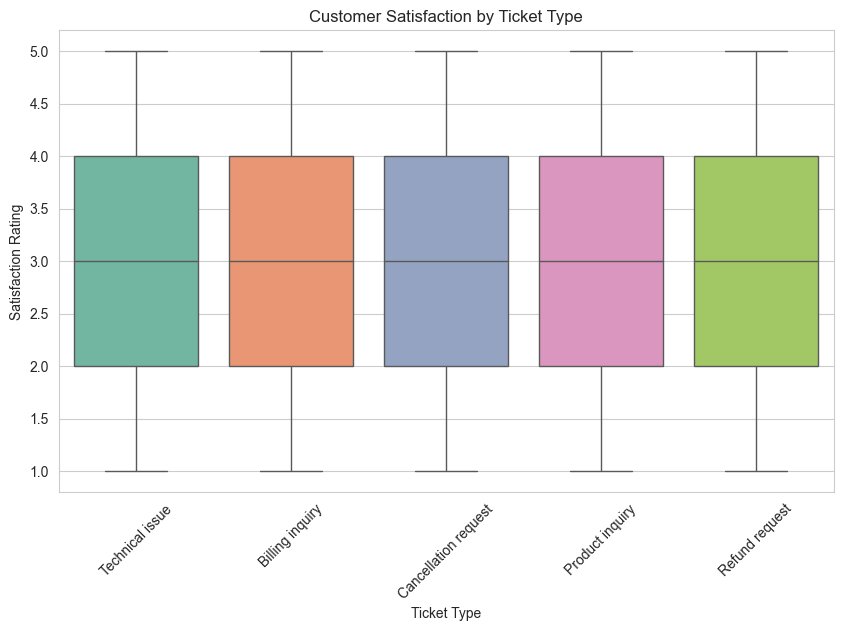

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Ticket Type',
    y='Customer Satisfaction Rating',
    data=data,
    palette='Set2'
)

plt.title("Customer Satisfaction by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Satisfaction Rating")

plt.xticks(rotation=45)

plt.show()

C:\Users\SAHILKUMAR\AppData\Local\Temp\ipykernel_14860\3099966230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


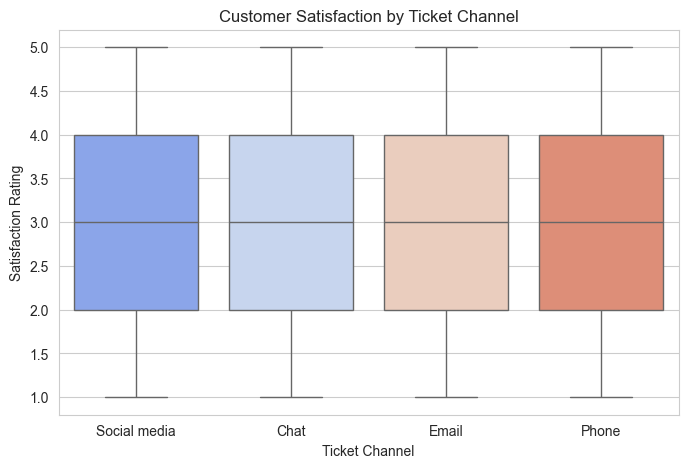

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Ticket Channel',
    y='Customer Satisfaction Rating',
    data=data,
    palette='coolwarm'
)

plt.title("Customer Satisfaction by Ticket Channel")
plt.xlabel("Ticket Channel")
plt.ylabel("Satisfaction Rating")

plt.show()

C:\Users\SAHILKUMAR\AppData\Local\Temp\ipykernel_14860\548416754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


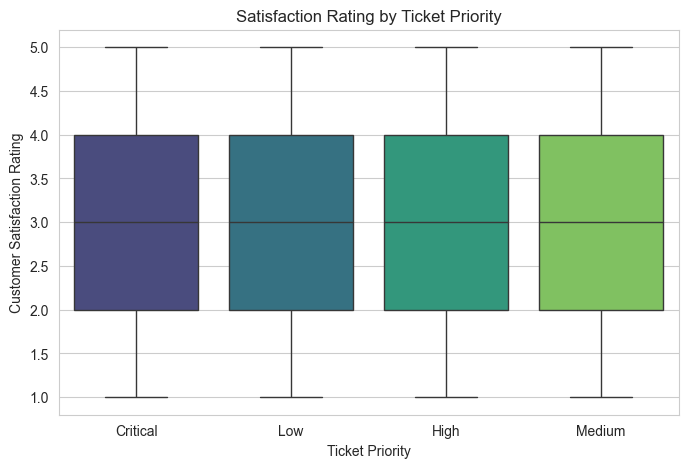

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Ticket Priority',
    y='Customer Satisfaction Rating',
    data=data,
    palette='viridis'
)

plt.title("Satisfaction Rating by Ticket Priority")
plt.xlabel("Ticket Priority")
plt.ylabel("Customer Satisfaction Rating")

plt.show()

C:\Users\SAHILKUMAR\AppData\Local\Temp\ipykernel_14860\1101243410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


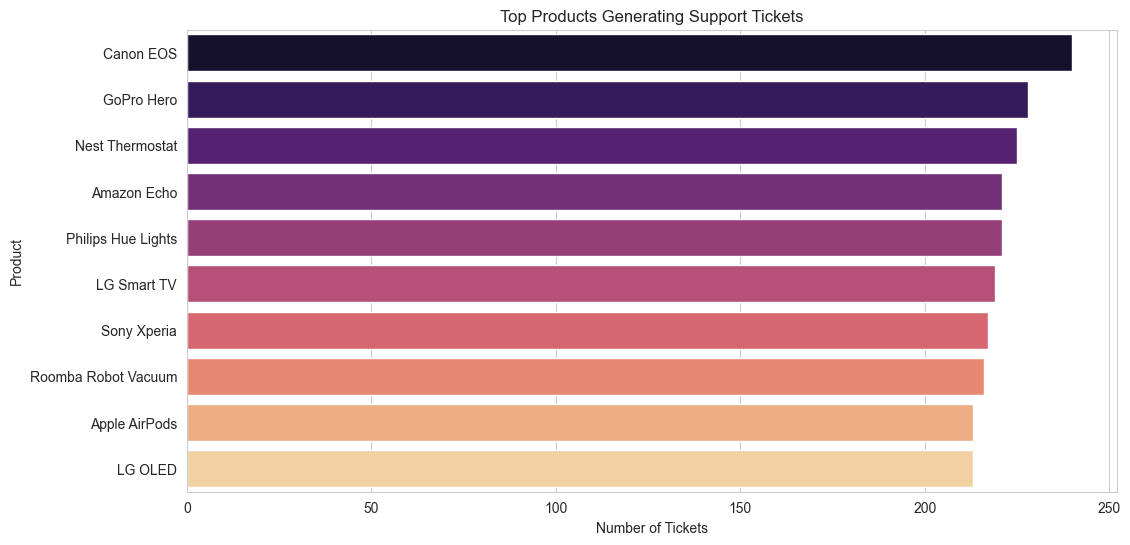

In [34]:
plt.figure(figsize=(12,6))

top_products = data['Product Purchased'].value_counts().head(10)

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='magma'
)

plt.title("Top Products Generating Support Tickets")
plt.xlabel("Number of Tickets")
plt.ylabel("Product")

plt.show()

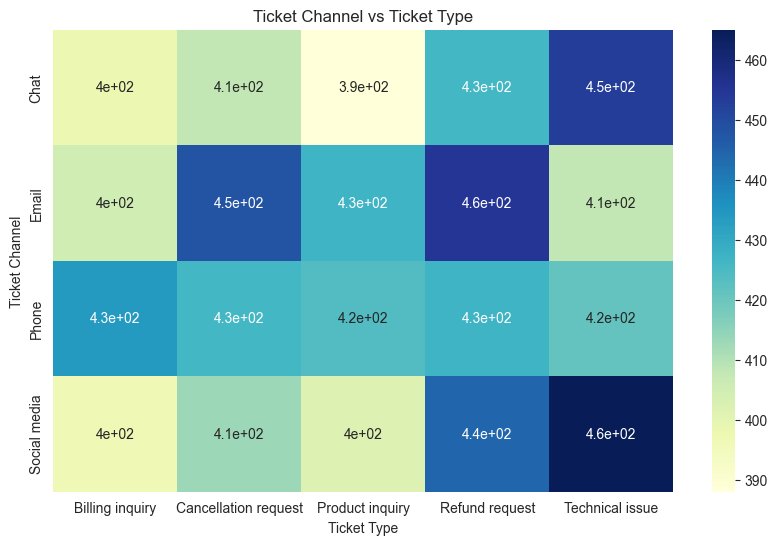

In [35]:
ticket_channel_type = pd.crosstab(
    data['Ticket Channel'],
    data['Ticket Type']
)

plt.figure(figsize=(10,6))

sns.heatmap(ticket_channel_type, annot=True, cmap='YlGnBu')

plt.title("Ticket Channel vs Ticket Type")

plt.show()

C:\Users\SAHILKUMAR\AppData\Local\Temp\ipykernel_14860\2920254811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


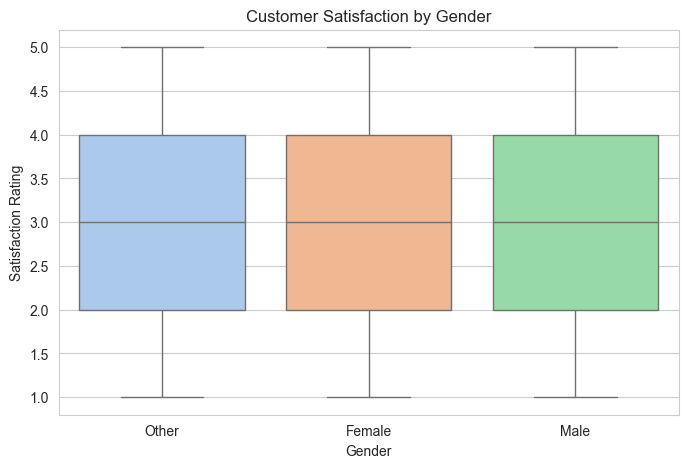

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Customer Gender',
    y='Customer Satisfaction Rating',
    data=data,
    palette='pastel'
)

plt.title("Customer Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Satisfaction Rating")

plt.show()

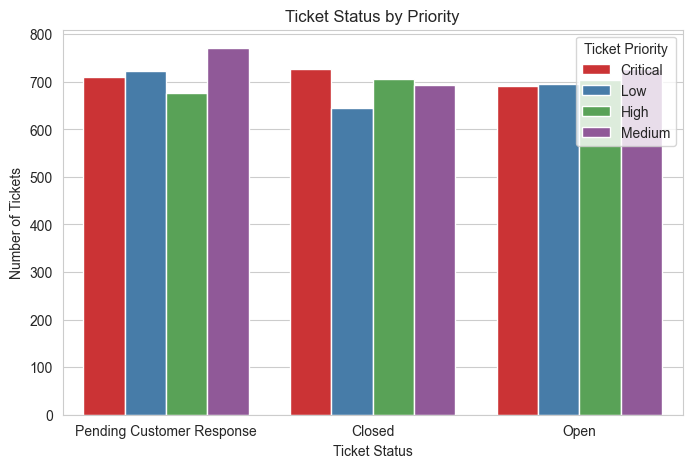

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Ticket Status',
    hue='Ticket Priority',
    data=data,
    palette='Set1'
)

plt.title("Ticket Status by Priority")
plt.xlabel("Ticket Status")
plt.ylabel("Number of Tickets")

plt.show()

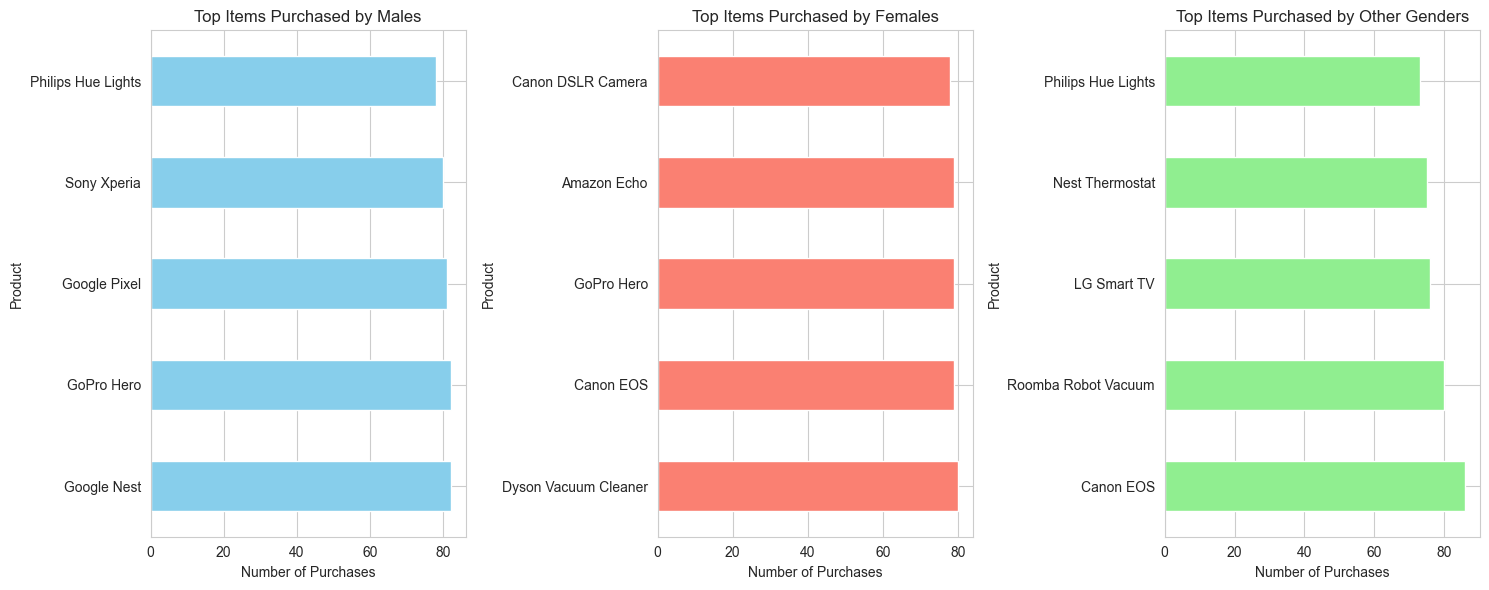

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Top products purchased by Male customers
plt.subplot(1,3,1)
top_items_male = data[data['Customer Gender']=='Male']['Product Purchased'].value_counts().head(5)
top_items_male.plot(kind='barh', color='skyblue')
plt.title('Top Items Purchased by Males')
plt.xlabel('Number of Purchases')
plt.ylabel('Product')

# Top products purchased by Female customers
plt.subplot(1,3,2)
top_items_female = data[data['Customer Gender']=='Female']['Product Purchased'].value_counts().head(5)
top_items_female.plot(kind='barh', color='salmon')
plt.title('Top Items Purchased by Females')
plt.xlabel('Number of Purchases')
plt.ylabel('Product')

# Top products purchased by Other gender
plt.subplot(1,3,3)
top_items_other = data[data['Customer Gender']=='Other']['Product Purchased'].value_counts().head(5)
top_items_other.plot(kind='barh', color='lightgreen')
plt.title('Top Items Purchased by Other Genders')
plt.xlabel('Number of Purchases')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

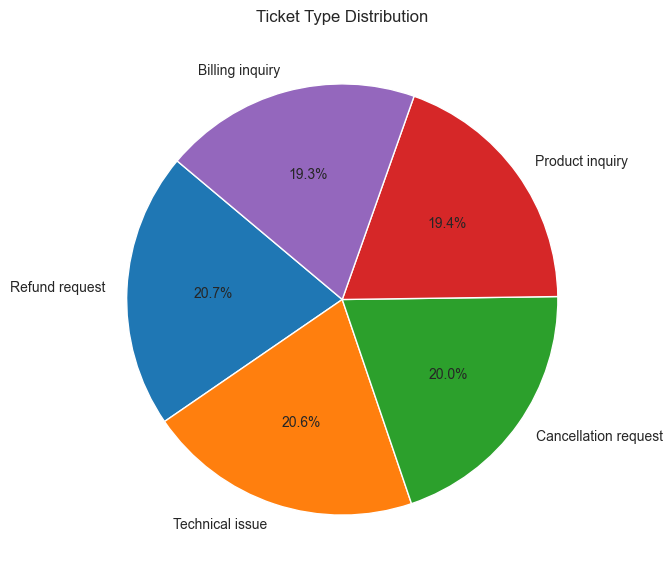

In [39]:
import matplotlib.pyplot as plt

# Count ticket types
ticket_type_counts = data['Ticket Type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    ticket_type_counts,
    labels=ticket_type_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Ticket Type Distribution")

plt.show()

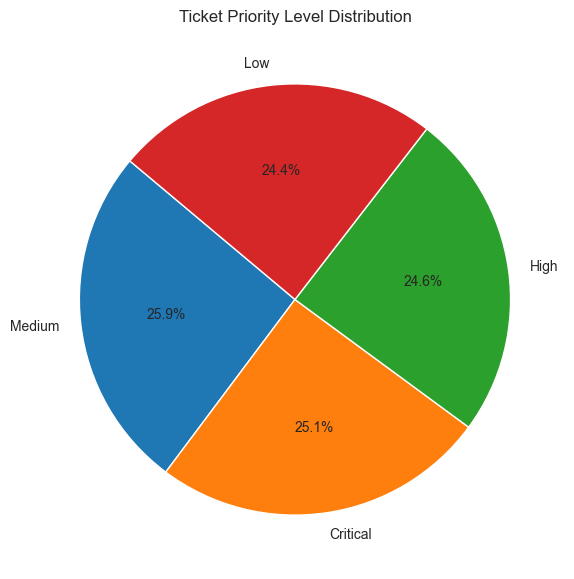

In [40]:
import matplotlib.pyplot as plt

# Count priority levels
priority_counts = data['Ticket Priority'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    priority_counts,
    labels=priority_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Ticket Priority Level Distribution")

plt.show()

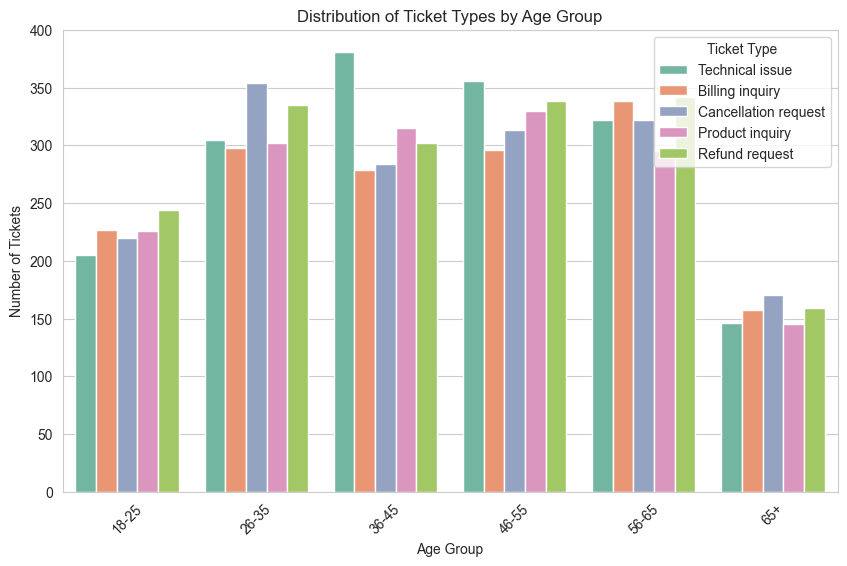

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create age groups
bins = [18,25,35,45,55,65,80]
labels = ['18-25','26-35','36-45','46-55','56-65','65+']

data['Age Group'] = pd.cut(data['Customer Age'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))

sns.countplot(
    x='Age Group',
    hue='Ticket Type',
    data=data,
    palette='Set2'
)

plt.title("Distribution of Ticket Types by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

In [43]:
ticket_type_dropdown = widgets.Dropdown(
    options=['All'] + list(data['Ticket Type'].unique()),
    value='All',
    description='Ticket Type'
)

channel_dropdown = widgets.Dropdown(
    options=['All'] + list(data['Ticket Channel'].unique()),
    value='All',
    description='Channel'
)

priority_dropdown = widgets.Dropdown(
    options=['All'] + list(data['Ticket Priority'].unique()),
    value='All',
    description='Priority'
)

In [44]:
def update_dashboard(ticket_type, channel, priority):

    filtered_data = data.copy()

    if ticket_type != 'All':
        filtered_data = filtered_data[filtered_data['Ticket Type'] == ticket_type]

    if channel != 'All':
        filtered_data = filtered_data[filtered_data['Ticket Channel'] == channel]

    if priority != 'All':
        filtered_data = filtered_data[filtered_data['Ticket Priority'] == priority]

    print("Filtered Records:", len(filtered_data))

    plt.figure(figsize=(18,12))

    # Ticket Type
    plt.subplot(2,3,1)
    filtered_data['Ticket Type'].value_counts().plot(kind='bar')
    plt.title("Ticket Type Distribution")

    # Ticket Channel
    plt.subplot(2,3,2)
    filtered_data['Ticket Channel'].value_counts().plot(kind='bar')
    plt.title("Ticket Channel Distribution")

    # Ticket Priority
    plt.subplot(2,3,3)
    filtered_data['Ticket Priority'].value_counts().plot(kind='bar')
    plt.title("Ticket Priority Distribution")

    # Age Distribution
    plt.subplot(2,3,4)
    sns.histplot(filtered_data['Customer Age'], bins=20, kde=True)
    plt.title("Customer Age Distribution")

    # Ticket Status Pie
    plt.subplot(2,3,5)
    filtered_data['Ticket Status'].value_counts().plot.pie(
        autopct='%1.1f%%'
    )
    plt.title("Ticket Status Distribution")

    # Satisfaction Distribution
    plt.subplot(2,3,6)
    filtered_data['Customer Satisfaction Rating'].value_counts().sort_index().plot(kind='bar')
    plt.title("Customer Satisfaction Distribution")

    plt.tight_layout()
    plt.show()

In [45]:
dashboard = widgets.interactive_output(
    update_dashboard,
    {
        'ticket_type': ticket_type_dropdown,
        'channel': channel_dropdown,
        'priority': priority_dropdown
    }
)

In [46]:
display(ticket_type_dropdown, channel_dropdown, priority_dropdown)
display(dashboard)

Dropdown(description='Ticket Type', options=('All', 'Technical issue', 'Billing inquiry', 'Cancellation reques…

Dropdown(description='Channel', options=('All', 'Social media', 'Chat', 'Email', 'Phone'), value='All')

Dropdown(description='Priority', options=('All', 'Critical', 'Low', 'High', 'Medium'), value='All')

Output(outputs=({'name': 'stdout', 'text': 'Filtered Records: 8469\n', 'output_type': 'stream'},))